In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.eval_measures import rmse
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df_daily=pd.read_csv("Final_data.csv")
df_daily.head()

,Datetime,Global_active_power
0,2006-12-16,3.053475
1,2006-12-17,2.354486
2,2006-12-18,1.530435
3,2006-12-19,1.157079
4,2006-12-20,1.545658


In [11]:
train_size = int(len(df_daily) * 0.8)
train, test = df_daily[:train_size], df_daily[train_size:]

# Fit Holt-Winters model with seasonality
model_hw = ExponentialSmoothing(
    train['Global_active_power'],
    trend='add',
    seasonal='mul',
    seasonal_periods=7  # since your data has 15 as seasonal period
).fit()
print(model_hw.summary())
# Forecast
pred_hw = model_hw.forecast(len(test))

                       ExponentialSmoothing Model Results                       
Dep. Variable:      Global_active_power   No. Observations:                 1146
Model:             ExponentialSmoothing   SSE                            106.223
Optimized:                         True   AIC                          -2703.751
Trend:                         Additive   BIC                          -2648.267
Seasonal:                Multiplicative   AICC                         -2703.430
Seasonal Periods:                     7   Date:                 Tue, 22 Apr 2025
Box-Cox:                          False   Time:                         14:29:38
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.2314613                alpha                 True
smoothing_trend          

In [10]:
import pandas as pd
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from itertools import product
import warnings

# Suppress convergence warnings
warnings.filterwarnings("ignore")

# Assume df_daily is already defined and has the necessary structure
# We'll split again just in case
train_size = int(len(df_daily) * 0.8)
train, test = df_daily[:train_size], df_daily[train_size:]

# Hyperparameter grid
trend_options = ['add', 'mul', None]
seasonal_options = ['add', 'mul', None]
damped_options = [True, False]
seasonal_periods_options = [7,10,15,20, 30]

# Store results
results = []

# Grid search over combinations
for trend, seasonal, damped, sp in product(trend_options, seasonal_options, damped_options, seasonal_periods_options):
    if seasonal is None and sp != 0:
        continue  # No seasonal component, no need to try seasonal periods

    try:
        model = ExponentialSmoothing(
            train['Global_active_power'],
            trend=trend,
            damped_trend=damped,
            seasonal=seasonal,
            seasonal_periods=sp if seasonal else None,
            initialization_method="estimated"
        )
        fitted_model = model.fit(optimized=True)
        y_pred = fitted_model.forecast(len(test))

        mae = mean_absolute_error(test['Global_active_power'], y_pred)
        rmse = np.sqrt(mean_squared_error(test['Global_active_power'], y_pred))
        r2 = r2_score(test['Global_active_power'], y_pred)

        results.append({
            'Trend': trend,
            'Seasonal': seasonal,
            'Damped': damped,
            'Seasonal Period': sp,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2
        })

    except Exception as e:
        # Skip any failed combinations
        continue

# Sort results by RMSE ascending
results_df = pd.DataFrame(results).sort_values(by='RMSE').reset_index(drop=True)
print(results_df)


   Trend Seasonal  Damped  Seasonal Period       MAE      RMSE         R2
0    add      mul   False                7  0.466852  0.544942  -2.003629
1    add      mul   False               30  0.544879  0.618789  -2.872849
2    add      mul   False               15  0.557145  0.628188  -2.991394
3    add      add   False               30  0.565184  0.636394  -3.096360
4    add      add   False               15  0.571807  0.641423  -3.161351
5    add      add   False               10  0.579648  0.649299  -3.264168
6    add      mul   False               10  0.579145  0.649346  -3.264793
7    mul      mul   False                7  0.584578  0.656558  -3.360055
8    add      add   False               20  0.584672  0.657178  -3.368286
9    add      mul   False               20  0.590175  0.664554  -3.466895
10   mul      mul    True               30  0.606932  0.678297  -3.653556
11  None      mul   False               30  0.607096  0.678663  -3.658580
12   add      mul    True             

In [12]:
mae_hw = mean_absolute_error(test['Global_active_power'], pred_hw)
rmse_hw = np.sqrt(mean_squared_error(test['Global_active_power'], pred_hw))
r2_hw = r2_score(test['Global_active_power'], pred_hw)

print(f"Holt-Winters Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_hw}")
print(f"Root Mean Squared Error (RMSE): {rmse_hw}")
print(f"R² Score: {r2_hw}")


Holt-Winters Model Evaluation:
Mean Absolute Error (MAE): 0.46685178043771874
Root Mean Squared Error (RMSE): 0.5449421625225845
R² Score: -2.003628620567057


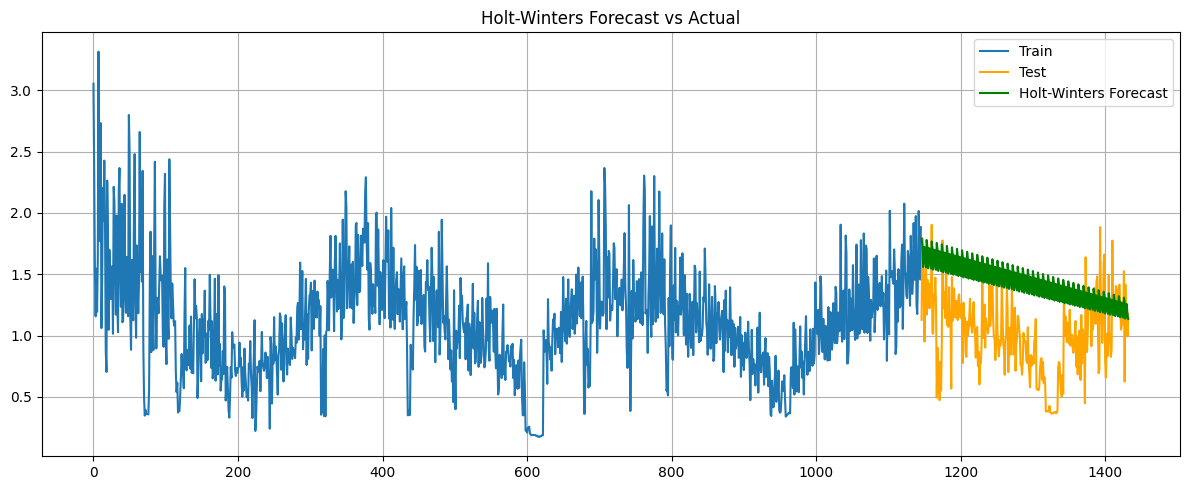

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train['Global_active_power'], label='Train')
plt.plot(test.index, test['Global_active_power'], label='Test', color='orange')
plt.plot(test.index, pred_hw, label='Holt-Winters Forecast', color='green')
plt.title('Holt-Winters Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
